In [14]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [15]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors
import matplotlib
import copy
import cmaps

In [16]:
savefig=True

rot = True

# Compare three files
if rot:
    nc_file1 = f'dcmip_lonlat_mountain_vortex.nc'
    nc_file2 = f'dcmip_lonlat_mountain_vortex_non_monotonic.nc'
else:
    nc_file1 = f'dcmip_lonlat_mountain_vortex_no_rotation.nc'
    nc_file2 = f'dcmip_lonlat_mountain_vortex_no_rotation_non_monotonic.nc'

In [17]:
run_path1 = '/glade/u/home/timand/LFRic_results/' + nc_file1
run_path2 = '/glade/u/home/timand/LFRic_results/' + nc_file2

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)

In [18]:
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 

print(np.size(lat), np.size(lon))

361 720


In [19]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat

lat_crop_up = 40.
lat_cent_down = 0.
lat_ticks = np.linspace(0,40,3)

lon_crop_left = 160.
lon_crop_right = 340.
lon_ticks = np.linspace(180., 340., 5)

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON, LAT = np.meshgrid(lon_crop, lat_crop)

lon_lfric = lon_inds - 180

print(np.shape(lon_crop))

(360,)


In [20]:
# Time index to compare at
t_idx = 80

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

title_size=16
label_size=14
small_size=12

In [21]:
# Interpolations of U and T
u1 = np.transpose(nc1['u'][lon_lfric, lat_inds])
v1 = np.transpose(nc1['v'][lon_lfric, lat_inds])
u2 = np.transpose(nc2['u'][lon_lfric, lat_inds])
v2 = np.transpose(nc2['v'][lon_lfric, lat_inds])

In [22]:
# Compute relative vorticity:
def compute_rel_vorticity(U, V, X, lat_crop, lon_crop):
    uv_ds = xr.Dataset(data_vars = dict(
        U=(['lat', 'lon'], U), V=(['lat', 'lon'], V)), coords = dict(lat=lat_crop, lon=lon_crop))
    uv_ds['U'].attrs["units"] = "m/s"
    uv_ds['V'].attrs["units"] = "m/s"

    # Return the scaled relative vorticity on the small Earth
    return X*mpcalc.vorticity(uv_ds['U'], uv_ds['V'])

# Small Earth factor
X=20

vort_1 = compute_rel_vorticity(u1, v1, X, lat_crop, lon_crop)
vort_2 = compute_rel_vorticity(u2, v2, X, lat_crop, lon_crop)

In [23]:
deg2rad = np.pi/180
T0 = 288
u0 = 10

# Normalised velocity perturbation:
U_field_vals1 = (u1 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals2 = (u2 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))

In [24]:
# What are the maximum values AWAY from the mountain??
lon_max_inds = np.where(np.logical_or((lon_crop <= 170),(lon_crop >= 190)))[0]

U_max_crop1 = U_field_vals1[:,lon_max_inds]
vort_max_crop1 = vort_1[:,lon_max_inds]

U_max_crop2 = U_field_vals2[:,lon_max_inds]
vort_max_crop2 = vort_2[:,lon_max_inds]


min value is -1.9582448
max value is 1.2004534


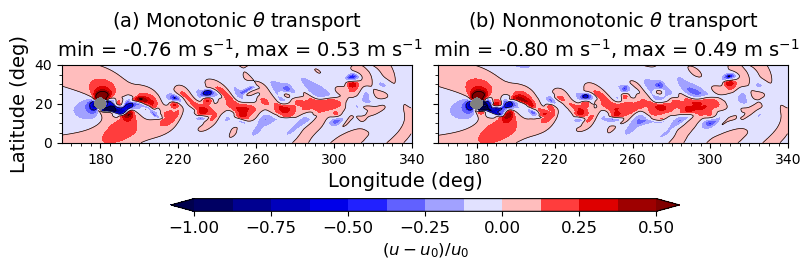

In [25]:
# Plot for U
U_cmap = matplotlib.cm.seismic
#U_cmap = matplotlib.cm.RdYlBu_r
#U_cmap.set_under('k')
#U_cmap.set_over('white')

#U_cmap = cmaps.ncl_default

U_max1 = np.nanmax(U_field_vals1)
U_max2 = np.nanmax(U_field_vals2)

U_min1 = np.nanmin(U_field_vals1)
U_min2 = np.nanmin(U_field_vals2)

U_maxmax = max(U_max1, U_max2)
U_minmin = min(U_min1, U_min2)

print('min value is', U_minmin)
print('max value is', U_maxmax)

fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,4), layout="constrained")
    
(ax1, ax2) = axes

U_conts = np.linspace(-1, 0.5, 13)
tick_range = np.linspace(-1, 0.5, 7)
norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=0.5)

U_conts_line = np.linspace(-1, 0.5, 4)


plot1 = ax1.contourf(LON, LAT, U_field_vals1, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, U_field_vals2, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
#plot4 = ax4.contourf(LON, LAT, U_field_vals4)
U_title = 'Normalised velocity perturbation'

# If we want contours overlaid:
ax1.contour(LON, LAT, U_field_vals1, levels = U_conts_line, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
ax2.contour(LON, LAT, U_field_vals2, levels = U_conts_line, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')

for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, shrink=0.7, aspect=40, pad=0.1, location='bottom')
cb.set_label(label=r"$(u - u_0)/u_0$", size=small_size)
cb.ax.tick_params(labelsize=12)

# Overall extrema
#ax1.set_title(f'{dycore1} \n min = {np.round(U_min1,2)}, max = {np.round(U_max1,2)}', size=label_size)
#ax2.set_title(f'{dycore2} \n min = {np.round(U_min2,2)}, max = {np.round(U_max2,2)}', size=label_size)
#ax3.set_title(f'{dycore3} \n min = {np.round(U_min3,2)}, max = {np.round(U_max3,2)}', size=label_size)
#ax4.set_title(f'{dycore4} \n min = {np.round(U_min4,2)}, max = {np.round(U_max4,2)}', size=label_size)

# Extrema away from the mountain
ax1.set_title(r'(a) Monotonic $\theta$' f' transport \n min = {np.min(U_max_crop1):.2f}' r" m s$^{-1}$" f', max = {np.max(U_max_crop1):.2f}' r" m s$^{-1}$", size=label_size)
ax2.set_title(r'(b) Nonmonotonic $\theta$' f' transport \n min = {np.min(U_max_crop2):.2f}' r" m s$^{-1}$" f', max = {np.max(U_max_crop2):.2f}' r" m s$^{-1}$", size=label_size)

ax1.set_ylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.5, y=0.18)

if savefig:
    if rot:
        plt.savefig('figures/vortex_gungho_montonicity_with_rot_U.png')
    else:
        plt.savefig('figures/vortex_gungho_montonicity_omega0_U.png')


min value is -0.004246666360682792
max value is 0.002517453347307193


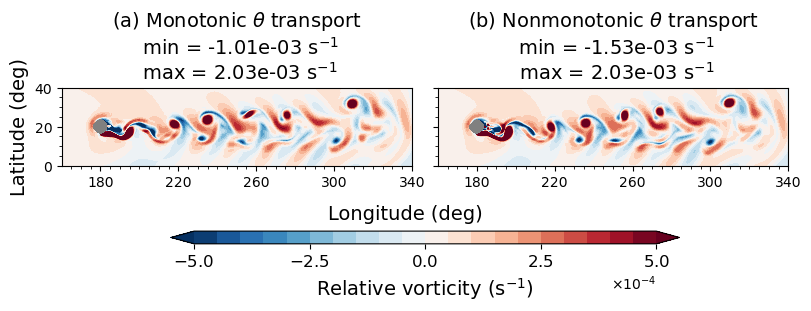

In [26]:
### T plot

cmap_choice = 'RdBu_r'

vort_max1 = np.nanmax(vort_1)
vort_max2 = np.nanmax(vort_2)

vort_min1 = np.nanmin(vort_1)
vort_min2 = np.nanmin(vort_2)

vort_maxmax = max(vort_max1, vort_max2)
vort_minmin = min(vort_min1, vort_min2)
absmax = 5e-4

print('min value is', vort_minmin)
print('max value is', vort_maxmax)

vort_conts = np.linspace(-absmax, absmax, 21)
vort_conts_line = np.linspace(-absmax, absmax, 3)
tick_range = np.linspace(-absmax, absmax, 5)
norm = colors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)

fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,5), layout="constrained")


(ax1, ax2) = axes
    
plot1 = ax1.contourf(LON, LAT, vort_1, levels = vort_conts, cmap=cmap_choice, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, vort_2, levels = vort_conts, cmap=cmap_choice, norm=norm, extend = 'both')

T_title = 'Temperature perturbation'
for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, shrink=0.7, aspect=40, pad=0.1, location='bottom')
cb.set_label(label='Relative vorticity (s$^{-1}$)', size=label_size)
cb.ax.tick_params(labelsize=12)
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)

# Extrema over the full domain
#ax1.set_title(f'{dycore1} \n min = {np.round(T_min1,2)} K, max = {np.round(T_max1,2)} K', size=label_size)
#ax2.set_title(f'{dycore2} \n min = {np.round(T_min2,2)} K, max = {np.round(T_max2,2)} K', size=label_size)
#ax3.set_title(f'{dycore3} \n min = {np.round(T_min3,2)} K, max = {np.round(T_max3,2)} K', size=label_size)
#ax4.set_title(f'{dycore4} \n min = {np.round(T_min4,2):.2f} K, max = {np.round(T_max4,2):.2f} K', size=label_size)

# Extrema away from the mountain
ax1.set_title(r'(a) Monotonic $\theta$' f' transport \n min = {np.nanmin(vort_max_crop1):.2e}' r" s$^{-1}$" f'\n max = {np.nanmax(vort_max_crop1):.2e}' r" s$^{-1}$", size=label_size)
ax2.set_title(r'(b) Nonmonotonic $\theta$' f' transport \n min = {np.nanmin(vort_max_crop2):.2e}' r" s$^{-1}$" f'\n max = {np.nanmax(vort_max_crop2):.2e}' r" s$^{-1}$", size=label_size)

ax1.set_ylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.5, y=0.16)

if savefig:
    if rot:
        plt.savefig('figures/vortex_gungho_montonicity_with_rot_vort.png', bbox_inches='tight')
    else:
        plt.savefig('figures/vortex_gungho_montonicity_omega0_vort.png', bbox_inches='tight')
